# **MLFlow com Keras**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import mlflow.tensorflow

# A GRANDE MUDANÇA: Tudo agora vem de 'tensorflow.keras'
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.datasets import mnist

# 'np_utils' foi removido. O substituto oficial é 'to_categorical'
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix

2025-12-27 10:13:53.203067: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-27 10:13:53.626664: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-27 10:13:55.825975: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Text(0.5, 1.0, '0')

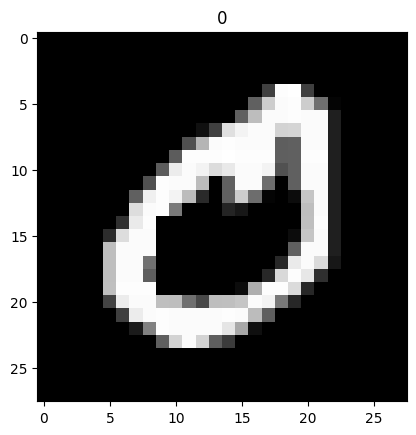

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
plt.imshow(X_train[21], cmap='gray')
plt.title(y_train[21])

In [3]:
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

In [4]:
X_test[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [4]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [5]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [6]:
y_test[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [7]:
def treina_dl(n_camadas_ocultas, n_units, activation, drop_out, epochs):
    # 1. CONFIGURAÇÃO DO MLFLOW (Resolve o erro de pasta corrompida)
    mlflow.set_tracking_uri("sqlite:///mlflow.db")
    mlflow.set_experiment("DLExperimento")

    with mlflow.start_run():
        # Autolog registra métricas e parâmetros automaticamente
        mlflow.tensorflow.autolog()

        # Registrando as tags
        mlflow.set_tag("n_camadas_ocultas", n_camadas_ocultas)
        mlflow.set_tag("n_units", n_units)
        mlflow.set_tag("activation", activation)
        mlflow.set_tag("drop_out",drop_out)
        mlflow.set_tag("epochs", epochs)

        modelo = Sequential()

        # 2. CORREÇÃO DO KERAS (Jeito moderno de definir entrada)
        # Substitui o input_dim=784 da camada Dense
        modelo.add(Input(shape=(784,)))

        # Primeira camada oculta
        modelo.add(Dense(units=n_units, activation=activation))
        modelo.add(Dropout(drop_out))

        # Camadas ocultas adicionais (Loop)
        for n in range(n_camadas_ocultas):
            modelo.add(Dense(units=n_units, activation=activation))
            modelo.add(Dropout(drop_out))

        # Camada de saída
        modelo.add(Dense(units=10, activation='softmax'))

        modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        modelo.summary()

        # Treinamento
        historico = modelo.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test))

        # 3. GRÁFICOS PERSONALIZADOS
        # Limpamos a figura antes de plotar para não sobrepor gráficos
        plt.figure()
        plt.plot(historico.history['val_loss'], label='Erro (Loss)')
        plt.title("Evolução do Erro")
        plt.legend()
        plt.savefig('loss.png')

        plt.figure()
        plt.plot(historico.history['val_accuracy'], label='Acurácia')
        plt.title("Evolução da Acurácia")
        plt.legend()
        plt.savefig("acuracia.png")

        # Registrar os gráficos manualmente (já que o autolog foca nas métricas numéricas)
        mlflow.log_artifact('loss.png')
        mlflow.log_artifact('acuracia.png')

        print(f"Modelo treinado! ID da Run: {mlflow.active_run().info.run_id}")

In [ ]:
n_camadas_ocultas = [1, 2, 4]
n_units = [16, 32, 64]
activation = ['relu', 'tanh']
drop_out = [0.1, 0.2]
epochs = [1, 3, 5]

for camadas in n_camadas_ocultas:
    for unidades in n_units:
        for ativacao in activation:
            for drop in drop_out:
                for epocas in epochs:
                    treina_dl(camadas, unidades, ativacao, drop, epocas)

2025/12/27 10:14:56 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/12/27 10:14:56 INFO mlflow.store.db.utils: Updating database tables
2025-12-27 10:14:56 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-27 10:14:56 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-12-27 10:14:56 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-12-27 10:14:56 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
E0000 00:00:1766841296.930140   10790 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1766841296.936547   10790 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,210 (231.29 KB)

 Trainable params: 59,210 (231.29 KB)

...

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9719 - loss: 0.0915 - val_accuracy: 0.9774 - val_loss: 0.0849
Epoch 18/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9725 - loss: 0.0894 - val_accuracy: 0.9755 - val_loss: 0.0894
Epoch 19/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9734 - loss: 0.0868 - val_accuracy: 0.9766 - val_loss: 0.0880
Epoch 20/50
1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9750 - loss: 0.0834

2025-12-27 10:17:09 WARNI [absl] You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9745 - loss: 0.0847 - val_accuracy: 0.9762 - val_loss: 0.0844
Epoch 21/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9747 - loss: 0.0859 - val_accuracy: 0.9767 - val_loss: 0.0902
Epoch 22/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9747 - loss: 0.0840 - val_accuracy: 0.9779 - val_loss: 0.0851
Epoch 23/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9750 - loss: 0.0813 - val_accuracy: 0.9756 - val_loss: 0.0920
Epoch 24/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9746 - loss: 0.0819 - val_accuracy: 0.9771 - val_loss: 0.0893
Epoch 25/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9759 - loss: 0.0799 - val_accuracy: 0.9778 - val_loss: 0.0894
Epoch 26/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9757 - loss: 0.0791 - val_accuracy: 0.9768 - val_loss: 0.0889
Epoch 27/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9764 - loss: 0.0776 - val

2025/12/27 10:20:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/27 10:20:32 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: (raised as a result of Query-invoked autoflush; consider using a session.no_autoflush block if this flush is occurring prematurely)
(sqlite3.IntegrityError) UNIQUE constraint failed: metrics.key, metrics.timestamp, metrics.step, metrics.run_uuid, metrics.value, metrics.is_nan
[SQL: INSERT INTO metrics ("key", value, timestamp, step, is_nan, run_uuid) VALUES (?, ?, ?, ?, ?, ?)]
[parameters: [('accuracy', 0.8623999953269958, 1766841309118, 0, 0, 'e5e7d977278f4515985a27acacb965fc'), ('loss', 0.4503653347492218, 1766841309118, 0, 0, 'e5e7d977278f4515985a27acacb965fc'), ('val_accuracy', 0.947700023651123, 1766841309118, 0, 0, 'e5e7d977278f4515985a27acacb965fc'), ('val_loss', 0.17360393702983856, 1766841309118, 0, 0, 'e5e7d977278f4515985a27acacb965fc')]]
(Background on

Modelo treinado! ID da Run: e5e7d977278f4515985a27acacb965fc


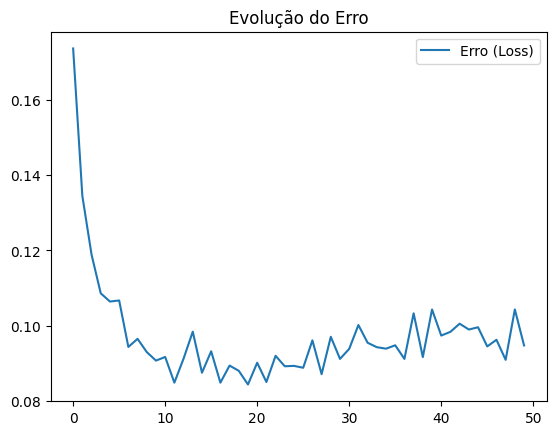

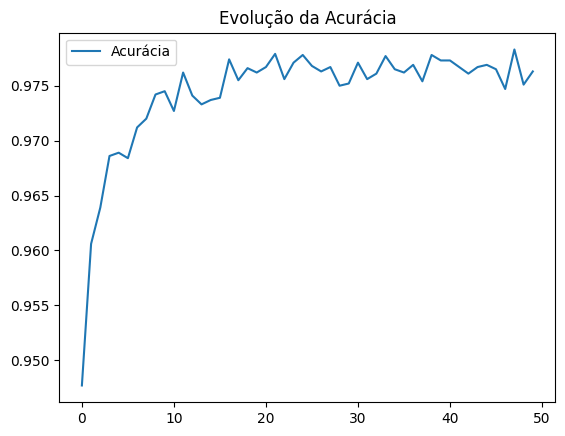

In [8]:
treina_dl(2, 64, 'relu', 0.2, 50)